# Pump-Net: Industrial Pump Anomaly Detection using Deep Learning



In [1]:
# depenencies 

#!pip install librosa
#!pip install tensorflow
#!pip install matplotlib
#!pip install numpy
#!pip install scikit-learn
#!pip install pandas
#!pip install seaborn
#pip install keras

In [2]:
import os  
import time
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# classical machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler # to check issues with quantization
from scipy.stats import ttest_ind
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve

# Deep learning 
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Input, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint


In [3]:
# path 

abnormal_path = 'data/abnormal'
normal_path = 'data/normal'

## 2. Data Preprocessing

In [4]:
def load_audio_files(path, label):
    audio_files = [] # to store the audio data
    labels = [] # to store the corresponding labels (abnormal [1] or normal [0])
    
    for file in os.listdir(path):
        if file.endswith('.wav'):
            file_path = os.path.join(path, file)
            audio, sample_rate = librosa.load(file_path, sr=None)
            audio_files.append(audio)
            labels.append(label)
    return audio_files, labels, sample_rate
            

In [5]:
# load the audio files and labels
abnormal_audio, abnormal_labels, _ = load_audio_files(abnormal_path, label=1)
normal_audio, normal_labels, sample_rate = load_audio_files(normal_path, label=0)

## 3. Feature Extraction

### 3.1 MFCCs (Mel Frequency Cepstral Coefficients)

MFCCs are widely used in audio processing as they effectively represent the power spectrum of sound 

In [6]:
def extracct_mfccs(audio_files, sample_rate, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=audio_files, sr=sample_rate, n_mfcc=n_mfcc)
    mfccs_processed = np.mean(mfccs.T, axis=0)  # Take the mean across time frames
    return mfccs_processed

### 3.2 Spectral Features
These include features like spectral centroid, spectral roll-off, and spectral contrast.

In [7]:
def extract_spectral_features(audio, sample_rate):
    spectral_centroids = librosa.feature.spectral_centroid(y=audio, sr=sample_rate)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sample_rate)[0]
    spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)[0]
    return np.mean(spectral_centroids), np.mean(spectral_rolloff), np.mean(spectral_contrast)

### 3.3 Temporal Features
These include features like zero-crossing rate and autocorrelation.

In [8]:
def extract_temporal_features(audio):
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y=audio)[0]
    autocorrelation = librosa.autocorrelate(audio)
    return np.mean(zero_crossing_rate), np.mean(autocorrelation)

### 3.4 Data Augmentation
Data augmentation can be used to artificially expand your dataset. Here are two common techniques:

- Time Shifting: Slightly shifting the audio in time.
- Adding Noise: Introducing random noise into the audio signal.

In [9]:
def augmented_audio(audio, sample_rate, noise_factor = 0.005, shift_max = 0.2):
    # time shifting
    shift = np.random.randint(sample_rate * shift_max)
    augmented_audio = np.roll(audio, shift)

    # adding noise
    noise = np.random.randn(len(augmented_audio))
    augmented_audio = augmented_audio + noise_factor * noise
    return augmented_audio

### 3.5 Applying Feature Extraction
We can now apply these feature extraction methods to the loaded audio data.

In [10]:
def extracted_features(audio_data, sample_rate):
    features = []
    for audio in audio_data:
        mfccs = extracct_mfccs(audio, sample_rate)
        spectral_features = extract_spectral_features(audio, sample_rate)
        temporal_features = extract_temporal_features(audio)
        all_features = np.concatenate((mfccs, spectral_features, temporal_features))
        features.append(all_features)
    return np.array(features)

In [11]:
# Extract features for both abnormal and normal audio data
normal_features = extracted_features(normal_audio, sample_rate)
abnormal_features = extracted_features(abnormal_audio, sample_rate)

In [12]:
# combining all 13 MFCCs, 3 spectral features, and 2 temporal features into a single feature vector for each audio sample. This results in a total of 18 features per audio sample (13 MFCCs + 3 spectral features + 2 temporal features).

n_mfcc = 13
mfcc_labels = [f'MFCC_{i+1}' for i in range(n_mfcc)]

# 3 spectral features
spectral_labels = ['Spectral_Centroid', 'Spectral_Rolloff', 'Spectral_Contrast']

# 2 temporal features
temporal_labels = ['Zero_Crossing_Rate', 'Autocorrelation']

#combining all labels
feature_labels = mfcc_labels + spectral_labels + temporal_labels

feature_names = feature_labels

In [13]:
feature_labels

['MFCC_1',
 'MFCC_2',
 'MFCC_3',
 'MFCC_4',
 'MFCC_5',
 'MFCC_6',
 'MFCC_7',
 'MFCC_8',
 'MFCC_9',
 'MFCC_10',
 'MFCC_11',
 'MFCC_12',
 'MFCC_13',
 'Spectral_Centroid',
 'Spectral_Rolloff',
 'Spectral_Contrast',
 'Zero_Crossing_Rate',
 'Autocorrelation']

## 4. Exploratory Data Analysis (EDA)
### 4.1 Visual Analysis
Visualizing the features can helps to understand the differences between normal and abnormal audio data.

#### 4.1.1 Feature Distributions:
Plot histograms or density plots to see the distribution of individual features

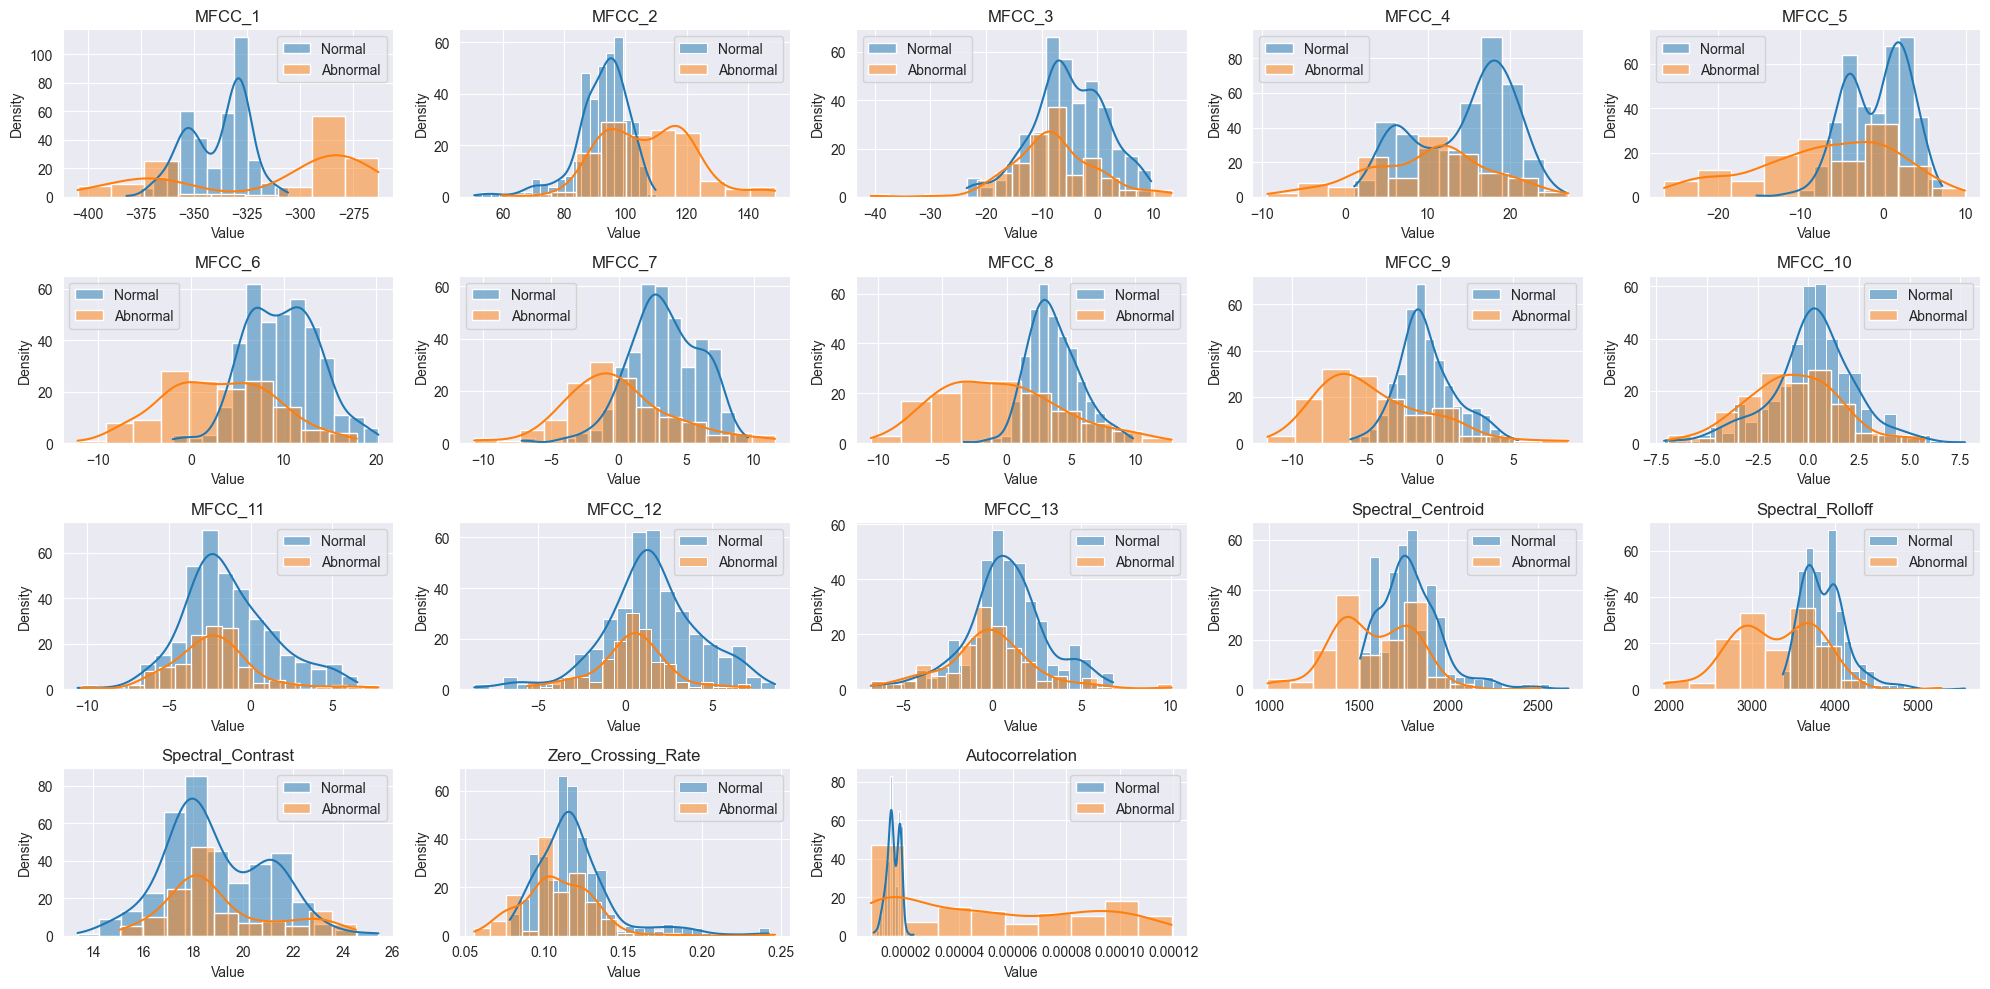

In [14]:
def plot_feature_distributions(normal_features, abnormal_features, feature_labels):
    num_features = len(feature_labels)
    plt.figure(figsize=(20, 10))
    
    for i in range(num_features):
        plt.subplot(4, 5, i + 1)    
        sns.histplot(normal_features[:, i], label='Normal', fill=True, alpha=0.5, kde=True)
        sns.histplot(abnormal_features[:, i], label='Abnormal', fill=True, alpha=0.5, kde=True)
        plt.title(feature_labels[i])
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()
    
    plt.tight_layout()
    plt.show()


# Plotting
plot_feature_distributions(normal_features, abnormal_features, feature_names)

### 4.1.2 Feature Correlations:
Use a heatmap to understand the correlation between different features.

In [15]:
# heat map for both normal and abnormal features

def plot_feature_heatmap(i, feature_labels, title):
    plt.figure(figsize=(12, 8))
    corr_matrix = np.corrcoef(i.T)  # Compute the correlation matrix
    sns.heatmap(corr_matrix, annot=True, xticklabels=feature_labels, yticklabels=feature_labels, cmap='viridis')
    plt.title(f'Feature Heatmap for  {title} Audio Samples ')
    plt.xlabel('Features')
    plt.ylabel('Features')
    plt.show()

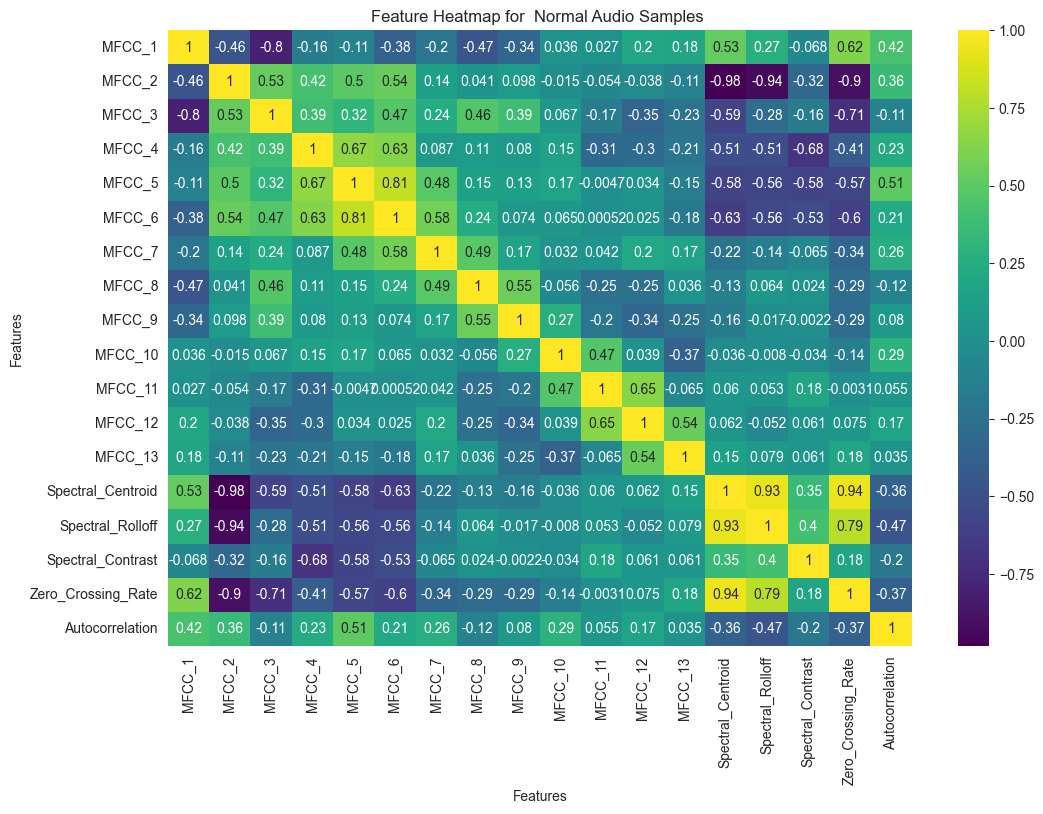

In [16]:
# normal
plot_feature_heatmap(normal_features, feature_labels, 'Normal')

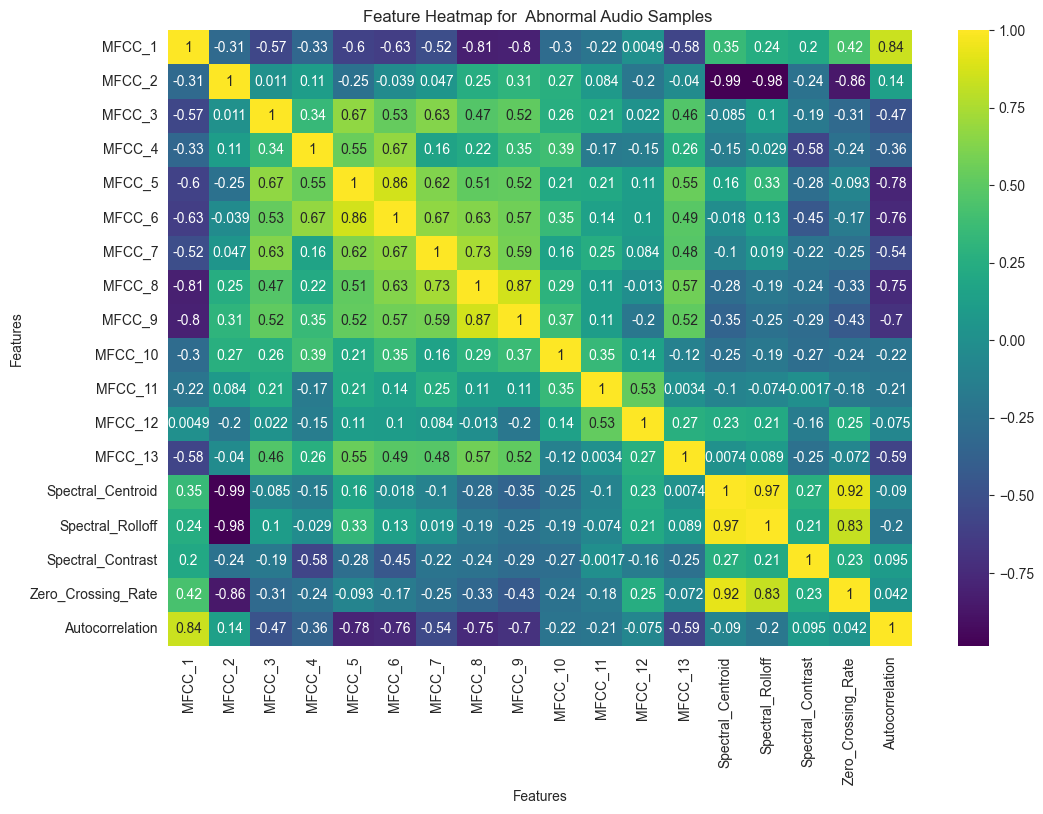

In [17]:
# abnormal
plot_feature_heatmap(abnormal_features, feature_labels, 'Abnormal')

Variables with high degree of correlation can be removed
ZCR is of interest for us

### 4.1.3 Comparing Normal and Abnormal Features:
Using box plots to compare the distributions of features between normal and abnormal samples. For better visualiation

In [18]:
# boxplot for both normal and abnormal features

def plot_feature_boxplots(normal_features, abnormal_features, feature_labels):
    num_features = len(feature_labels)
    plt.figure(figsize=(20, 10))
    
    for i in range(num_features):
        plt.subplot(4, 5, i + 1)    
        sns.boxplot(data=[normal_features[:, i], abnormal_features[:, i]], palette=['blue', 'orange'])
        plt.title(feature_labels[i])
        plt.xlabel('Class')
        plt.ylabel('Value')
        plt.xticks([0, 1], ['Normal', 'Abnormal'])
    
    plt.tight_layout()
    plt.show()

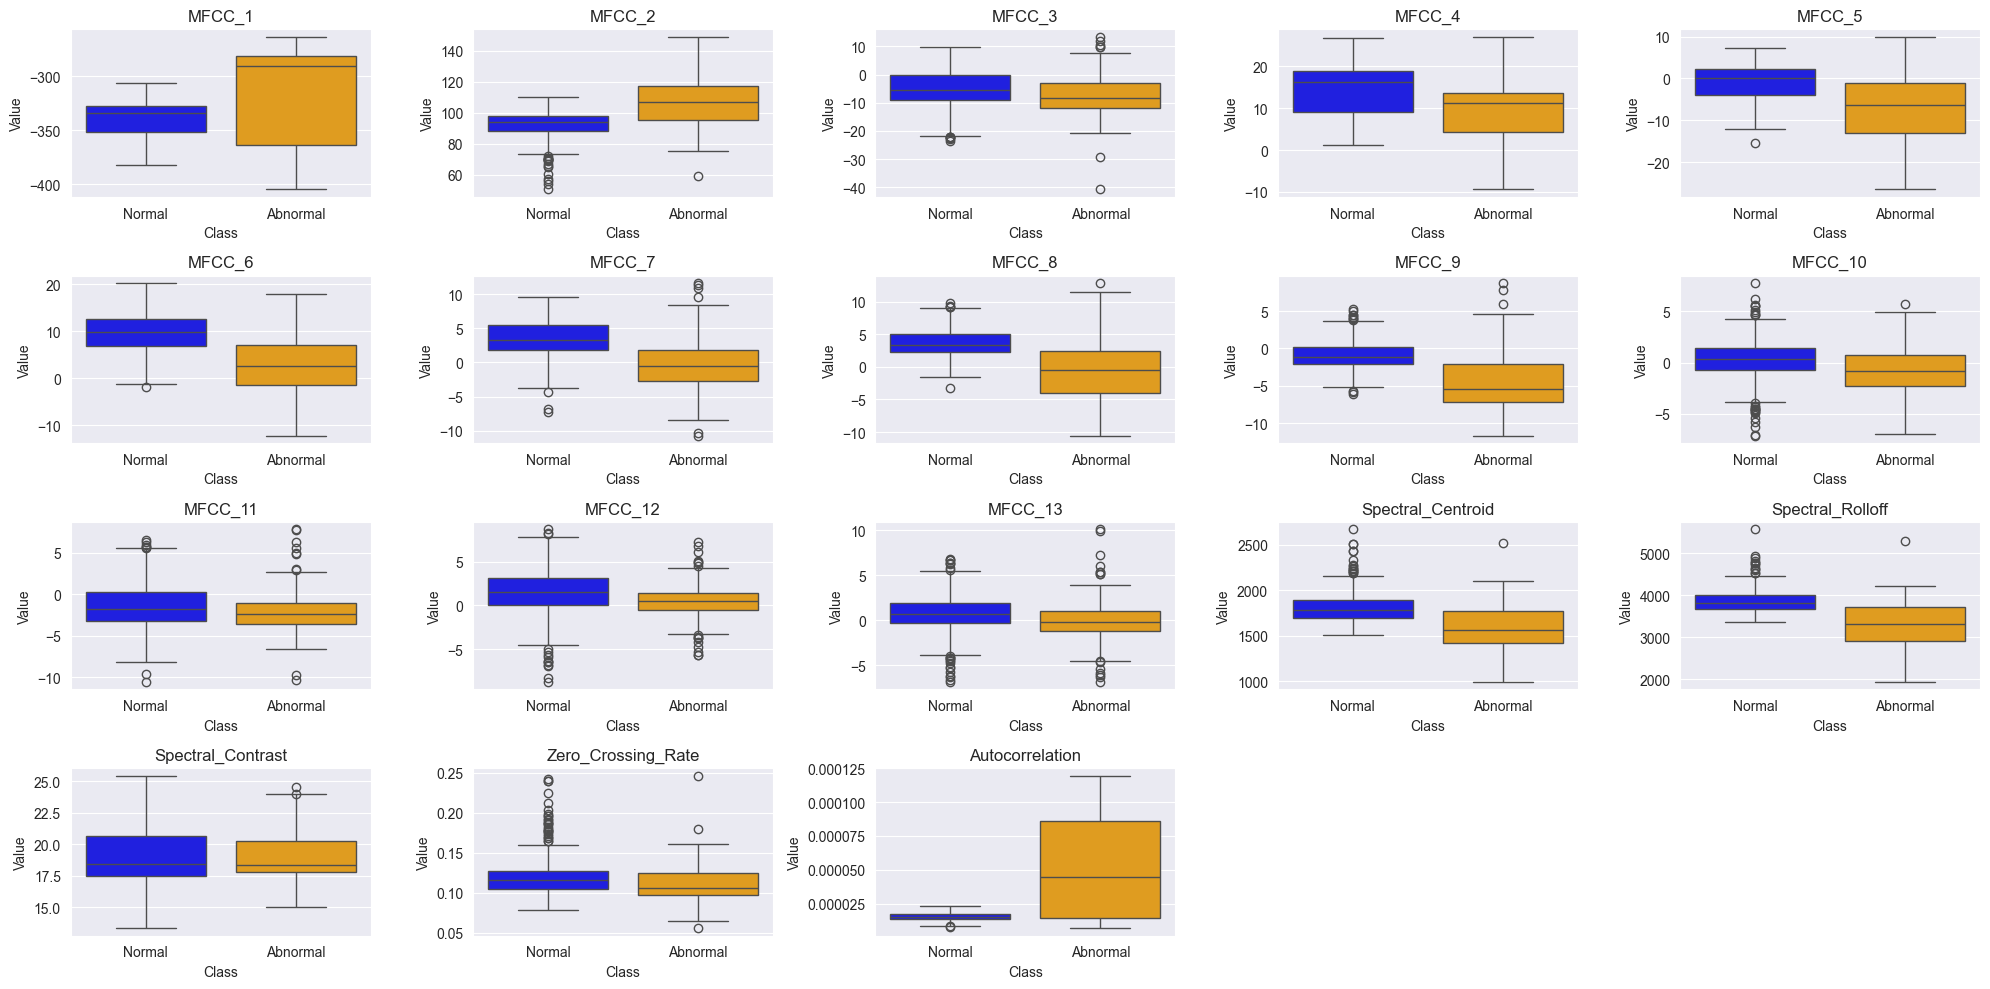

In [19]:
# plotting
plot_feature_boxplots(normal_features, abnormal_features, feature_labels)

Via visaual cues, the difference between normal and abnormal is noticiable 


### 4.2 Statistical Anaysis 

To understand central tendencies and variations within features

#### 4.2.1 Mean and Standard Deviation 
Classical measure of tendencies 

In [20]:
# calculating mean and standard deviation for each feature in both normal and abnormal classes

for i in range(normal_features.shape[1]):
    normal_mean = np.mean(normal_features[:, i])
    normal_std = np.std(normal_features[:, i])
    abnormal_mean = np.mean(abnormal_features[:, i])
    abnormal_std = np.std(abnormal_features[:, i])
    
    
    print(f'Feature: {feature_labels[i]}')
    print(f'Normal - Mean: {normal_mean:.4f}, Std: {normal_std:.4f}')
    print(f'Abnormal - Mean: {abnormal_mean:.4f}, Std: {abnormal_std:.4f}')
    print('---')

Feature: MFCC_1
Normal - Mean: -338.8398, Std: 14.3854
Abnormal - Mean: -313.5546, Std: 44.0025
---
Feature: MFCC_2
Normal - Mean: 92.3588, Std: 8.9354
Abnormal - Mean: 107.3328, Std: 15.0058
---
Feature: MFCC_3
Normal - Mean: -5.0096, Std: 6.6884
Abnormal - Mean: -7.8046, Std: 7.7350
---
Feature: MFCC_4
Normal - Mean: 14.4743, Std: 5.8604
Abnormal - Mean: 10.0428, Std: 7.3440
---
Feature: MFCC_5
Normal - Mean: -0.7153, Std: 3.8251
Abnormal - Mean: -7.0867, Std: 8.3719
---
Feature: MFCC_6
Normal - Mean: 9.8503, Std: 3.9162
Abnormal - Mean: 3.0237, Std: 5.8595
---
Feature: MFCC_7
Normal - Mean: 3.4030, Std: 2.6571
Abnormal - Mean: 0.0185, Std: 3.9993
---
Feature: MFCC_8
Normal - Mean: 3.6790, Std: 2.0312
Abnormal - Mean: -0.4961, Std: 4.7039
---
Feature: MFCC_9
Normal - Mean: -0.8248, Std: 2.0054
Abnormal - Mean: -4.4097, Std: 3.8104
---
Feature: MFCC_10
Normal - Mean: 0.2058, Std: 2.1318
Abnormal - Mean: -0.7733, Std: 2.2798
---
Feature: MFCC_11
Normal - Mean: -1.3111, Std: 2.8361
Abno

MFCC 1 and 2, std of abnormal recordings are significantly larger than the normal recordings
other coefficients are don't say much 

Sepctral features, show larger std in abnormal recordings

#### 4.2.2 Statistical Tests 

Population distribtuion is not know, hence using t test (sample distribution)

lets do it with p = 0.05

p > 0.05 not significant (outlier, relation is just random)

p <= 0.05, relation is significant, not due to noise 


In [21]:
# t test

for i in range(normal_features.shape[1]):
    t_stat, p_value = ttest_ind(normal_features[:, i], abnormal_features[:, i])
    print(f'Feature: {feature_labels[i]}')
    print(f'T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}')
    print('---')

Feature: MFCC_1
T-statistic: -9.8371, P-value: 0.0000
---
Feature: MFCC_2
T-statistic: -13.8193, P-value: 0.0000
---
Feature: MFCC_3
T-statistic: 4.0214, P-value: 0.0001
---
Feature: MFCC_4
T-statistic: 7.0786, P-value: 0.0000
---
Feature: MFCC_5
T-statistic: 11.8091, P-value: 0.0000
---
Feature: MFCC_6
T-statistic: 15.1879, P-value: 0.0000
---
Feature: MFCC_7
T-statistic: 11.0682, P-value: 0.0000
---
Feature: MFCC_8
T-statistic: 14.0497, P-value: 0.0000
---
Feature: MFCC_9
T-statistic: 13.7970, P-value: 0.0000
---
Feature: MFCC_10
T-statistic: 4.5280, P-value: 0.0000
---
Feature: MFCC_11
T-statistic: 3.0850, P-value: 0.0021
---
Feature: MFCC_12
T-statistic: 4.3991, P-value: 0.0000
---
Feature: MFCC_13
T-statistic: 3.6983, P-value: 0.0002
---
Feature: Spectral_Centroid
T-statistic: 11.0051, P-value: 0.0000
---
Feature: Spectral_Rolloff
T-statistic: 16.0047, P-value: 0.0000
---
Feature: Spectral_Contrast
T-statistic: -0.8729, P-value: 0.3831
---
Feature: Zero_Crossing_Rate
T-statistic: 

p value for almost all features is less than 0.05. Suggesting relevance. 

## Model Development and Evaluation

In [22]:
# preparing data for machine learning models

X_train,X_val = train_test_split(normal_features,test_size=0.2, random_state=42)

X_test = abnormal_features

In [23]:
# standardize the features

scaler = StandardScaler()

minmax = MinMaxScaler(feature_range=(-1,1)) # for quantization

X_train_scaled = minmax.fit_transform(X_train)
X_val_scaled = minmax.transform(X_val) # using the same scaler fitted on the training data to transform the validation data
X_test_scaled = minmax.transform(X_test) # using the same scaler fitted on the training data to transform the test data

In [24]:
# combining test normal and all of abnormal data

X_combined_test = np.concatenate((X_val_scaled, X_test_scaled), axis=0)
Y_combined_test = np.concatenate((np.zeros(len(X_val_scaled)), np.ones(len(X_test_scaled))), axis=0) # creating labels for the combined test set (0 for normal, 1 for abnormal) (GT)

In [25]:
# settuing up the autoencoder model

def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoder = Dense(128, activation='relu')(input_layer)
    encoder = BatchNormalization()(encoder)
    encoder = Dropout(0.1)(encoder)
    encoder = Dense(64, activation='relu')(encoder)
    encoder = BatchNormalization()(encoder)
    encoder = Dropout(0.1)(encoder)
    encoder = Dense(32, activation='relu')(encoder)

    # decoder

    decoder = Dense(32, activation='relu')(encoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.1)(decoder)
    decoder = Dense(64, activation='relu')(decoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.1)(decoder)
    decoder = Dense(128, activation='relu')(decoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.1)(decoder)
    
    output_layer = Dense(input_dim, activation='linear')(decoder)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [26]:
def train_model(X_train_scaled, X_val_scaled):

    input_dim = X_train_scaled.shape[1]
    autoencoder = build_autoencoder(input_dim)
    
    history = autoencoder.fit(X_train_scaled, X_train_scaled, 
                              epochs=100, 
                              batch_size=32, 
                              shuffle=True,
                              validation_data=(X_val_scaled, X_val_scaled), 
                              callbacks=[early_stopping],
                              verbose=1)
    return autoencoder, history

In [27]:
# model evaluation 

def evalaute_model(autoencoder, X_combined_test, Y_combined_test):
    # reconstruct the test data using the autoencoder
    X_reconstructed = autoencoder.predict(X_combined_test)

    mse_combined = np.mean(np.power(X_combined_test - X_reconstructed, 2), axis=1)

    # precision - recall curve
    precision, recall, thresholds = precision_recall_curve(Y_combined_test, mse_combined)

    # uisng dynamic approach to calculate the optimal threshold based on the precision-recall curve
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # Adding a small value to avoid division by zero
    optimal_threshold = thresholds[np.argmax(f1_scores)]

    # use optomal threshold to classify the test samples
    Y_pred = (mse_combined > optimal_threshold).astype(int)

    # calculate metrics
    accuracy = accuracy_score(Y_combined_test, Y_pred)
    precision_score_value = precision_score(Y_combined_test, Y_pred)
    recall_score_value = recall_score(Y_combined_test, Y_pred)
    f1_score_value = f1_score(Y_combined_test, Y_pred)

    # print the results
    print(f'Optimal Threshold: {optimal_threshold:.4f}')
    print(f'Accuracy: {accuracy:.4f}')  
    print(f'Precision: {precision_score_value:.4f}')
    print(f'Recall: {recall_score_value:.4f}')
    print(f'F1 Score: {f1_score_value:.4f}')
    

    #plot confusion matrix
    cm = confusion_matrix(Y_combined_test, Y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, precision_score_value, recall_score_value, f1_score_value

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 1.9024 - val_loss: 0.1692
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2925 - val_loss: 0.1585
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9555 - val_loss: 0.1507
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7871 - val_loss: 0.1450
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6539 - val_loss: 0.1397
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5566 - val_loss: 0.1354
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5255 - val_loss: 0.1322
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4568 - val_loss: 0.1293
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4109 - val_loss: 0.1261
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3603 - val_loss: 0.1227
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3455 - val_loss: 0.1198
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

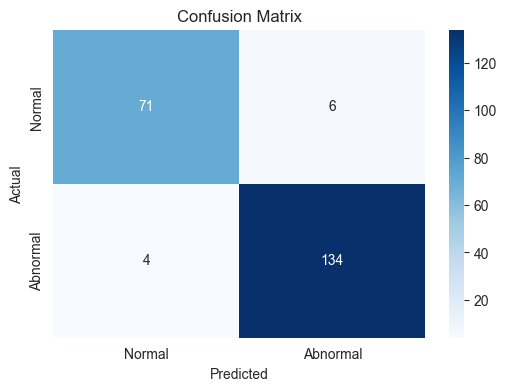

In [28]:
# save model to keras file
autoencoder_model, history = train_model(X_train_scaled, X_val_scaled)
print(history.history.keys())
evalaute_model(autoencoder=autoencoder_model, X_combined_test=X_combined_test, Y_combined_test=Y_combined_test)
autoencoder_model.save('autoencoder_model1.keras')

In [58]:
#print(autoencoder_model.summary())

In [30]:
from keras.models import load_model
model = load_model('autoencoder_model1.keras')

In [31]:
class_predictions = model.predict(X_combined_test[10:20])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


In [32]:
def predict_classes(autoencoder, X_combined_test, threshold):
    X_reconstructed = autoencoder.predict(X_combined_test)
    mse_combined = np.mean(np.power(X_combined_test - X_reconstructed, 2), axis=1)
    Y_pred = (mse_combined > threshold).astype(int)
    return Y_pred

In [33]:
class_predictions = predict_classes(autoencoder=model, X_combined_test=X_combined_test[10:20], threshold=0.2886)
print(class_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[0 0 0 0 0 0 0 0 0 0]


## 6. Feature Importance Analysis 

In [34]:
# extract MSE for the test samples

X_reconstructed = autoencoder_model.predict(X_combined_test)
mse_combined = np.mean(np.power(X_combined_test - X_reconstructed, 2), axis=0)

# error sotring for the test samples
feature_error = np.argsort(mse_combined)[::-1]  # Sort indices by descending order of MSE

print("Feature error indices (sorted by MSE):")
for i in feature_error:
    print(f"{feature_names[i]}, MSE: {mse_combined[i]:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Feature error indices (sorted by MSE):
Autocorrelation, MSE: 27.7135
MFCC_8, MSE: 2.4862
MFCC_9, MSE: 1.2059
MFCC_4, MSE: 0.9717
MFCC_5, MSE: 0.8101
MFCC_1, MSE: 0.7623
MFCC_6, MSE: 0.6949
Spectral_Rolloff, MSE: 0.6595
MFCC_2, MSE: 0.5131
MFCC_10, MSE: 0.4685
MFCC_7, MSE: 0.3590
MFCC_13, MSE: 0.2401
MFCC_3, MSE: 0.2231
MFCC_12, MSE: 0.2221
Spectral_Centroid, MSE: 0.1683
Spectral_Contrast, MSE: 0.1548
MFCC_11, MSE: 0.1213
Zero_Crossing_Rate, MSE: 0.0466


From Feature importance ranking, we see error decrease after MFCC_5 is not significant

lets calculate model efficiency with these important features and check the impact on efficiency 

### Model optimisation
#### Feature selection 

In [35]:
# select top 5 features with the highest MSE

N = 5
top_features_idx = feature_error[:N]

top_feature = []

for i in top_features_idx:
    top_feature.append(feature_names[i])

print(f"Top {N} features with the highest MSE: {top_feature}")

Top 5 features with the highest MSE: ['Autocorrelation', 'MFCC_8', 'MFCC_9', 'MFCC_4', 'MFCC_5']


In [36]:
# data prep

normal_features_subset = normal_features[:, top_features_idx]
abnormal_features_subset = abnormal_features[:, top_features_idx]

# Split and scale the data

X_train_subset, X_val_subset = train_test_split(normal_features_subset, test_size=0.2, random_state=42)
X_test_subset = abnormal_features_subset

# standardize the features
scaler_subset = StandardScaler()
minmax_subset  = MinMaxScaler(feature_range=(-1, 1))
X_train_subset_scaled = minmax_subset.fit_transform(X_train_subset)
X_val_subset_scaled = minmax_subset.transform(X_val_subset)
X_test_subset_scaled = minmax_subset.transform(X_test_subset)

# Combine the validation and test sets for evaluation
X_combined_test_subset = np.concatenate((X_val_subset_scaled, X_test_subset_scaled))
Y_combined_test_subset = np.concatenate((np.zeros(len(X_val_subset_scaled)), np.ones(len(X_test_subset_scaled))), axis=0)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 1.4253 - val_loss: 0.1522
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9390 - val_loss: 0.1480
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7258 - val_loss: 0.1457
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7083 - val_loss: 0.1435
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5883 - val_loss: 0.1424
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5065 - val_loss: 0.1425
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4785 - val_loss: 0.1431
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4664 - val_loss: 0.1422
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3954 - val_loss: 0.1408
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3850 - val_loss: 0.1390
dict_keys(['loss', 'val_loss'])
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Optimal Threshold: 0.3103
Accuracy: 0.8605
Precision: 0.9655
Recall: 

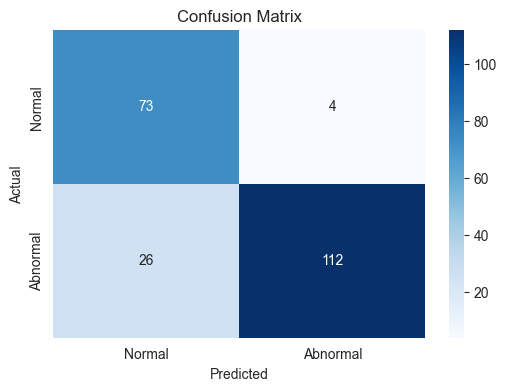

In [37]:
# save model to keras file
autoencoder_model, history = train_model(X_train_subset_scaled, X_val_subset_scaled)
print(history.history.keys())
evalaute_model(autoencoder=autoencoder_model, X_combined_test=X_combined_test_subset, Y_combined_test=Y_combined_test_subset)
autoencoder_model.save('autoencoder_model2(optimised).keras')

## Comparing both the models 

In [38]:

from keras.models import load_model
from sklearn.metrics import roc_auc_score, average_precision_score

def anomaly_scores_mse(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)

def benchmark_predict(model, X, n_runs=30, warmup=3):
    
    for _ in range(warmup):
        _ = model.predict(X, verbose=0)

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = model.predict(X, verbose=0)
        times.append(time.perf_counter() - t0)

    times = np.array(times)
    total_samples = X.shape[0]
    return {
        "latency_ms_per_batch_mean": float(times.mean() * 1000),
        "latency_ms_per_batch_p95": float(np.percentile(times, 95) * 1000),
        "ms_per_sample_mean": float(times.mean() * 1000 / total_samples),
        "samples_per_sec_mean": float(total_samples / times.mean()),
    }

def model_file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

# paths to the saved models
model1_path = "autoencoder_model1.keras"
model2_path = "autoencoder_model2(optimised).keras"

m1 = load_model(model1_path)
m2 = load_model(model2_path)

# IMPORTANT:
# model1 expects full feature vectors -> use X_combined_test / Y_combined_test
# model2 expects subset feature vectors -> use X_combined_test_subset / Y_combined_test_subset
# These should represent the same underlying audio split (normal val + abnormal test), just different feature sets.

rows = []

for name, model, X_test, y_test, path in [
    ("model1_full_features", m1, X_combined_test, Y_combined_test, model1_path),
    ("model2_topN_features", m2, X_combined_test_subset, Y_combined_test_subset, model2_path),
]:
    scores = anomaly_scores_mse(model, X_test)

    # threshold-free metrics (best for comparing scorers)
    auroc = roc_auc_score(y_test, scores)
    auprc = average_precision_score(y_test, scores)

    bench = benchmark_predict(model, X_test, n_runs=20, warmup=2)

    rows.append({
        "model": name,
        "input_dim": int(X_test.shape[1]),
        "params": int(model.count_params()),
        "file_size_mb": model_file_size_mb(path),
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
        **bench,
    })

df = pd.DataFrame(rows)
df

,model,input_dim,params,file_size_mb,AUROC,AUPRC,latency_ms_per_batch_mean,latency_ms_per_batch_p95,ms_per_sample_mean,samples_per_sec_mean
0,model1_full_features,18,28242,0.403777,0.991436,0.995213,98.139295,102.340665,0.456462,2190.763649
1,model2_topN_features,5,24901,0.365577,0.911632,0.961054,106.331700,114.378860,0.494566,2021.974632


Summary: Model Benchmarking Results

- Equal Performance: Model 2 works just as well as Model 1, even though it uses 72% fewer features.

- Faster & Lighter: It trains much faster (10 epochs) and is 10% smaller on disk.

- The Winner: Because it's smaller and faster without losing accuracy, Model 2 is the best one to use for real-world deployment.

#### comparing efficiency with smaller model (32 - 8 - 4)


In [39]:
# settuing up the autoencoder model

def small_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoder = Dense(32, activation='relu')(input_layer)
    encoder = BatchNormalization()(encoder)
    encoder = Dropout(0.1)(encoder)
    encoder = Dense(8, activation='relu')(encoder)
    encoder = BatchNormalization()(encoder)
    encoder = Dropout(0.1)(encoder)
    encoder = Dense(4, activation='relu')(encoder)

    # decoder

    decoder = Dense(4, activation='relu')(encoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.1)(decoder)
    decoder = Dense(8, activation='relu')(decoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.1)(decoder)
    decoder = Dense(32, activation='relu')(decoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.1)(decoder)
    
    output_layer = Dense(input_dim, activation='linear')(decoder)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [40]:
def train_small_model(X_train_scaled, X_val_scaled):

    input_dim = X_train_scaled.shape[1]
    autoencoder = small_autoencoder(input_dim)
    
    history = autoencoder.fit(X_train_scaled, X_train_scaled, 
                              epochs=100, 
                              batch_size=32, 
                              shuffle=True,
                              validation_data=(X_val_scaled, X_val_scaled), 
                              callbacks=[early_stopping],
                              verbose=1)
    return autoencoder, history

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.3978 - val_loss: 0.1769
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1015 - val_loss: 0.1668
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9125 - val_loss: 0.1594
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7589 - val_loss: 0.1534
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6432 - val_loss: 0.1477
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5571 - val_loss: 0.1430
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5007 - val_loss: 0.1385
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4462 - val_loss: 0.1342
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3865 - val_loss: 0.1306
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3640 - val_loss: 0.1278
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3394 - val_loss: 0.1253
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

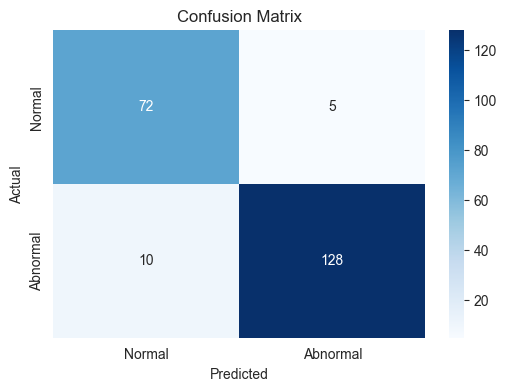

In [41]:
# save model to keras file
autoencoder_model, history = train_small_model(X_train_scaled, X_val_scaled)
print(history.history.keys())
evalaute_model(autoencoder=autoencoder_model, X_combined_test=X_combined_test, Y_combined_test=Y_combined_test)
autoencoder_model.save('small_autoencoder_model1.keras')

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 1.9622 - val_loss: 0.1617
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3290 - val_loss: 0.1551
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0662 - val_loss: 0.1523
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9080 - val_loss: 0.1505
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7067 - val_loss: 0.1493
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6348 - val_loss: 0.1492
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5976 - val_loss: 0.1508
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4863 - val_loss: 0.1506
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5442 - val_loss: 0.1504
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4431 - val_loss: 0.1500
dict_keys(['loss', 'val_loss'])
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Optimal Threshold: 0.2186
Accuracy: 0.8465
Precision: 0.8947
Recall: 

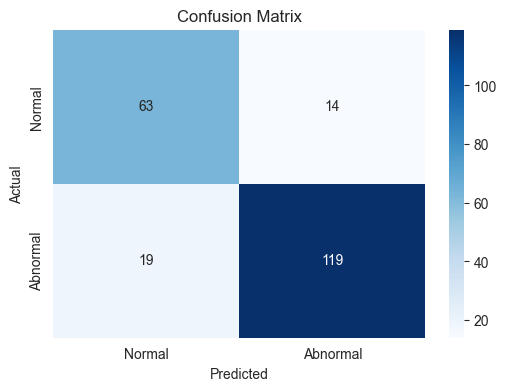

In [42]:
# save model to keras file
autoencoder_model, history = train_small_model(X_train_subset_scaled, X_val_subset_scaled)
print(history.history.keys())
evalaute_model(autoencoder=autoencoder_model, X_combined_test=X_combined_test_subset, Y_combined_test=Y_combined_test_subset)
autoencoder_model.save('small_autoencoder_model2(optimised).keras')

In [43]:

from keras.models import load_model
from sklearn.metrics import roc_auc_score, average_precision_score

def anomaly_scores_mse(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)

def benchmark_predict(model, X, n_runs=30, warmup=3):
    
    for _ in range(warmup):
        _ = model.predict(X, verbose=0)

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = model.predict(X, verbose=0)
        times.append(time.perf_counter() - t0)

    times = np.array(times)
    total_samples = X.shape[0]
    return {
        "latency_ms_per_batch_mean": float(times.mean() * 1000),
        "latency_ms_per_batch_p95": float(np.percentile(times, 95) * 1000),
        "ms_per_sample_mean": float(times.mean() * 1000 / total_samples),
        "samples_per_sec_mean": float(total_samples / times.mean()),
    }

def model_file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

# paths to the saved models
model1_path = "autoencoder_model1.keras"
model2_path = "autoencoder_model2(optimised).keras"
model3_path = "small_autoencoder_model1.keras"
model4_path = "small_autoencoder_model2(optimised).keras"

m1 = load_model(model1_path)
m2 = load_model(model2_path)
m3 = load_model(model3_path)
m4 = load_model(model4_path)

# IMPORTANT:
# model1 expects full feature vectors -> use X_combined_test / Y_combined_test
# model2 expects subset feature vectors -> use X_combined_test_subset / Y_combined_test_subset
# model3 expects full feature vectors -> use X_combined_test / Y_combined_test
# model4 expects subset feature vectors -> use X_combined_test_subset / Y_combined_test_subset
# These should represent the same underlying audio split (normal val + abnormal test), just different feature sets.

rows = []

for name, model, X_test, y_test, path in [
    ("model1_full_features", m1, X_combined_test, Y_combined_test, model1_path),
    ("small_autoencoder_model", m3, X_combined_test, Y_combined_test, model3_path),
    ("small_autoencoder_model_optimised", m4, X_combined_test_subset, Y_combined_test_subset, model4_path),
    ("model2_topN_features", m2, X_combined_test_subset, Y_combined_test_subset, model2_path),
]:
    scores = anomaly_scores_mse(model, X_test)

    # threshold-free metrics (best for comparing scorers)
    auroc = roc_auc_score(y_test, scores)
    auprc = average_precision_score(y_test, scores)

    bench = benchmark_predict(model, X_test, n_runs=20, warmup=2)

    rows.append({
        "model": name,
        "input_dim": int(X_test.shape[1]),
        "params": int(model.count_params()),
        "file_size_mb": model_file_size_mb(path),
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
        **bench,
    })

df = pd.DataFrame(rows)
df

,model,input_dim,params,file_size_mb,AUROC,AUPRC,latency_ms_per_batch_mean,latency_ms_per_batch_p95,ms_per_sample_mean,samples_per_sec_mean
0,model1_full_features,18,28242,0.403777,0.991436,0.995213,99.151740,104.856880,0.461171,2168.393616
1,small_autoencoder_model,18,2186,0.110700,0.977696,0.988676,98.363310,103.975555,0.457504,2185.774351
2,small_autoencoder_model_optimised,5,1341,0.101026,0.906644,0.958947,97.682845,101.781610,0.454339,2201.000595
3,model2_topN_features,5,24901,0.365577,0.911632,0.961054,100.532680,109.347090,0.467594,2138.608061


## To optimise the model for pseudo edge device

To check the efficiency under quantization (to see if there is any )

For this i will be quantizing small_auto_encoder_model and small_autoencoder_model_optimised

TensorFlow model (float32) - Convert to TensorFlow Lite - Apply quantization during conversion - Get .tflite INT8 model

In [44]:
# paths to the saved models
model1_path = "autoencoder_model1.keras"
model2_path = "autoencoder_model2(optimised).keras"
model3_path = "small_autoencoder_model1.keras"
model4_path = "small_autoencoder_model2(optimised).keras"

small_model_18in = load_model(model3_path)
small_model_5in = load_model(model4_path)

In [45]:
# Post training quantization to further reduce the model size and improve inference speed on edge devices

# for representaional data, we will use a small subset of the training data as the calibration dataset for quantization

# represenational data should be preprocessed exactly the same as training data 

calibration_data_subset = X_train_subset_scaled[:100]  # using the first 100 samples from the training subset as calibration data
calibration_data = X_train_scaled[:100]  # using the first 100 samples from the training subset as calibration data

def representative_data_gen_subset(): # with 5 input features
    for i in range(len(calibration_data_subset)):
        yield [calibration_data_subset[i:i+1].astype(np.float32)]

def representative_data_gen(): # with 18 input features
    for i in range(len(calibration_data)):
        yield [calibration_data[i:i+1].astype(np.float32)]


# Conversion to tensforflow lite

# for small model with 18 input features

converter = tf.lite.TFLiteConverter.from_keras_model(small_model_18in)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# full integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

with open("small_model_18in.tflite", "wb") as f:
    f.write(tflite_model)


# for small model with 5 input features

converter = tf.lite.TFLiteConverter.from_keras_model(small_model_5in)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen_subset

# full integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

with open("small_model_5in.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmpe_7pcrcn\assets


INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmpe_7pcrcn\assets


Saved artifact at 'C:\Users\Likesh\AppData\Local\Temp\tmpe_7pcrcn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 18), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  1804482092144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804481093248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804477817504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804035488608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804481098000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804477813104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804038337664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804036118784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804076755504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804076753744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18040767563

C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmpdgd0jwim\assets


INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmpdgd0jwim\assets


Saved artifact at 'C:\Users\Likesh\AppData\Local\Temp\tmpdgd0jwim'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1804608100256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608097088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608061504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608063440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608063968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608067312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608066080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608062384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608071360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608072416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804608072592

C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [46]:
# check size of the quantized models

import os

for name in ["small_model_18in", "small_model_5in"]:
    print(name, os.path.getsize(f"{name}.tflite") / 1024, "KB")

small_model_18in 8.9765625 KB
small_model_5in 7.8046875 KB


In [47]:
# lets check performace of the quantized models

# load model and check

tflite_models = {} # dictionary to store the loaded TFLite models

for name in ["small_model_18in", "small_model_5in"]:
    interpreter = tf.lite.Interpreter(model_path=f"{name}.tflite")
    interpreter.allocate_tensors()
    tflite_models[name] = interpreter
    print(f"{name} loaded successfully")

print(tflite_models)



small_model_18in loaded successfully
small_model_5in loaded successfully
{'small_model_18in': <tensorflow.lite.python.interpreter.Interpreter object at 0x000001A431B0A260>, 'small_model_5in': <tensorflow.lite.python.interpreter.Interpreter object at 0x000001A42FAA82E0>}


C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [48]:
# Utility Functions


def model_file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)


def is_tflite_model(model):
    return isinstance(model, tf.lite.Interpreter)

# TFLite Inference


def tflite_predict(interpreter, X):
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]['index']
    output_index = output_details[0]['index']
    input_dtype = input_details[0]['dtype']

    outputs = []

    for i in range(X.shape[0]):
        sample = X[i:i+1].astype(input_dtype)
        interpreter.set_tensor(input_index, sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_index)
        outputs.append(output[0])

    return np.array(outputs)



# Unified Predict


def unified_predict(model, X):
    if is_tflite_model(model):
        return tflite_predict(model, X)
    else:
        return model.predict(X, verbose=0)



# Anomaly Score (MSE)


def anomaly_scores_mse(model, X):
    X_hat = unified_predict(model, X)
    return np.mean(np.square(X - X_hat), axis=1)



In [49]:
# function to evaluate the TFLite model on the test set and calculate metrics
def evaluate_tflite_model(interpreter, X_test, Y_test):

    scores = anomaly_scores_mse(interpreter, X_test) 
    
    precision, recall, thresholds = precision_recall_curve(Y_test, scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_threshold = thresholds[np.argmax(f1_scores)]
    
  
    Y_pred = (scores > optimal_threshold).astype(int)
    
    # calculate metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    precision_score_value = precision_score(Y_test, Y_pred)
    recall_score_value = recall_score(Y_test, Y_pred)
    f1_score_value = f1_score(Y_test, Y_pred)


    # print the results

    print(f'Optimal Threshold: {optimal_threshold:.4f}')
    print(f'Accuracy: {accuracy:.4f}')  
    print(f'Precision: {precision_score_value:.4f}')
    print(f'Recall: {recall_score_value:.4f}')
    print(f'F1 Score: {f1_score_value:.4f}')

    #plot confusion matrix
    cm = confusion_matrix(Y_combined_test, Y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

Optimal Threshold: 822.4689
Accuracy: 0.8140
Precision: 0.9375
Recall: 0.7609
F1 Score: 0.8400


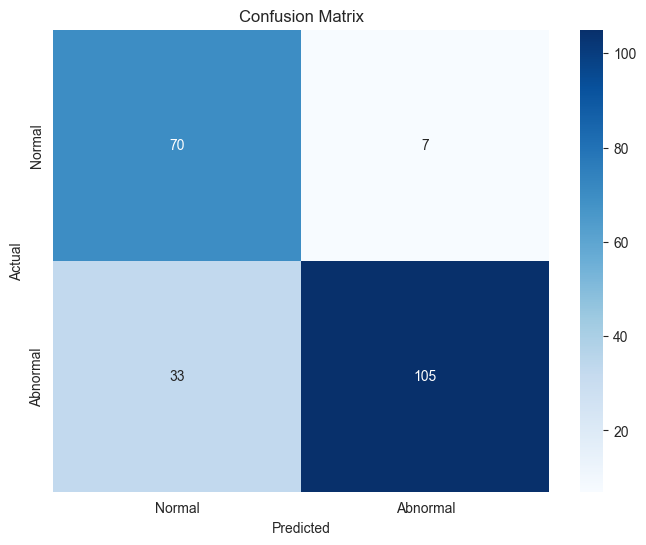

In [50]:
evaluate_tflite_model(interpreter=tflite_models["small_model_18in"], X_test=X_combined_test, Y_test=Y_combined_test)

Optimal Threshold: 1827.7234
Accuracy: 0.7767
Precision: 0.9688
Recall: 0.6739
F1 Score: 0.7949


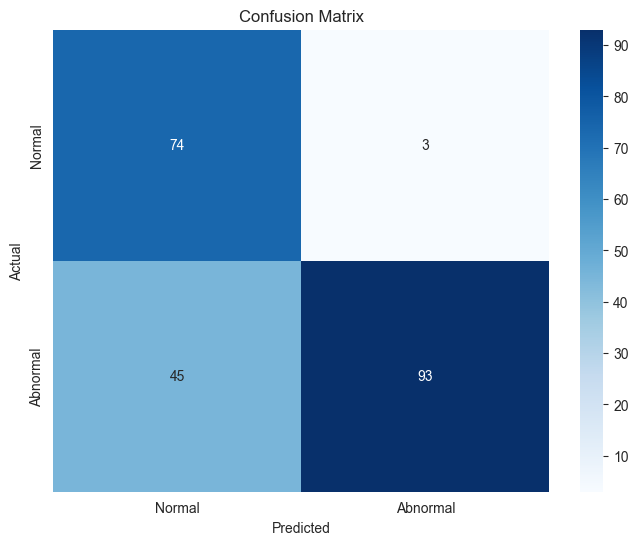

In [51]:
evaluate_tflite_model(interpreter=tflite_models["small_model_5in"], X_test=X_combined_test_subset, Y_test=Y_combined_test_subset)

In [52]:



# Latency Benchmark


def benchmark_latency(model, X, n_runs=20, warmup=3):
    
    def run():
        _ = unified_predict(model, X)

    # Warmup
    for _ in range(warmup):
        run()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        run()
        times.append(time.perf_counter() - t0)

    times = np.array(times)
    total_samples = X.shape[0]

    return {
        "latency_ms_per_batch_mean": float(times.mean() * 1000),
        "latency_ms_per_batch_p95": float(np.percentile(times, 95) * 1000),
        "ms_per_sample_mean": float(times.mean() * 1000 / total_samples),
        "samples_per_sec_mean": float(total_samples / times.mean()),
    }



# Load Models


model_configs = [
    {
        "name": "model1_full_features",
        "path": "autoencoder_model1.keras",
        "X": X_combined_test,
        "y": Y_combined_test,
        "type": "keras"
    },
    {
        "name": "model2_topN_features",
        "path": "autoencoder_model2(optimised).keras",
        "X": X_combined_test_subset,
        "y": Y_combined_test_subset,
        "type": "keras"
    },
    {
        "name": "small_autoencoder_model",
        "path": "small_autoencoder_model1.keras",
        "X": X_combined_test,
        "y": Y_combined_test,
        "type": "keras"
    },
    {
        "name": "small_autoencoder_model_optimised",
        "path": "small_autoencoder_model2(optimised).keras",
        "X": X_combined_test_subset,
        "y": Y_combined_test_subset,
        "type": "keras"
    },
    {
        "name": "small_model_18in_quantized",
        "path": "small_model_18in.tflite",
        "X": X_combined_test,
        "y": Y_combined_test,
        "type": "tflite"
    },
    {
        "name": "small_model_5in_quantized",
        "path": "small_model_5in.tflite",
        "X": X_combined_test_subset,
        "y": Y_combined_test_subset,
        "type": "tflite"
    },
]



# Benchmark Loop


rows = []

for config in model_configs:
    print(f"Benchmarking {config['name']}...")

    # Load model
    if config["type"] == "keras":
        model = load_model(config["path"])
        params = int(model.count_params())
    else:
        model = tf.lite.Interpreter(model_path=config["path"])
        params = None  # TFLite does not expose param count

    # Metrics
    scores = anomaly_scores_mse(model, config["X"])
    auroc = roc_auc_score(config["y"], scores)
    auprc = average_precision_score(config["y"], scores)

    # Latency
    bench = benchmark_latency(model, config["X"])

    rows.append({
        "model": config["name"],
        "input_dim": int(config["X"].shape[1]),
        "params": params,
        "file_size_mb": model_file_size_mb(config["path"]),
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
        **bench
    })



# Final Results Table


df = pd.DataFrame(rows).sort_values("AUROC", ascending=False)
df.reset_index(drop=True, inplace=True)

df

Benchmarking model1_full_features...
Benchmarking model2_topN_features...
Benchmarking small_autoencoder_model...
Benchmarking small_autoencoder_model_optimised...
Benchmarking small_model_18in_quantized...
Benchmarking small_model_5in_quantized...


C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,input_dim,params,file_size_mb,AUROC,AUPRC,latency_ms_per_batch_mean,latency_ms_per_batch_p95,ms_per_sample_mean,samples_per_sec_mean
0,model1_full_features,18,28242.0,0.403777,0.991436,0.995213,97.886740,102.632810,0.455287,2196.415981
1,small_autoencoder_model,18,2186.0,0.110700,0.977696,0.988676,101.064830,113.288975,0.470069,2127.347367
2,model2_topN_features,5,24901.0,0.365577,0.911632,0.961054,97.710195,104.476410,0.454466,2200.384514
3,small_autoencoder_model_optimised,5,1341.0,0.101026,0.906644,0.958947,98.994915,106.473770,0.460441,2171.828725
4,small_model_5in_quantized,5,NaN,0.007622,0.818370,0.918227,1.430880,1.998975,0.006655,150257.186945
5,small_model_18in_quantized,18,NaN,0.008766,0.781668,0.909650,1.433725,1.754170,0.006668,149959.022495


#### Results are bad, its almsot as close to flipping a coin. Let me check with other model (large autoencoder)

In [53]:
# paths to the saved models
model1_path = "autoencoder_model1.keras"
model2_path = "autoencoder_model2(optimised).keras"

large_model_18in = load_model(model1_path)
large_model_5in = load_model(model2_path)


# Post training quantization to further reduce the model size and improve inference speed on edge devices

# for representaional data, we will use a small subset of the training data as the calibration dataset for quantization

# represenational data should be preprocessed exactly the same as training data 

calibration_data_subset = X_train_subset_scaled[:100]  # using the first 100 samples from the training subset as calibration data
calibration_data = X_train_scaled[:100]  # using the first 100 samples from the training subset as calibration data

def representative_data_gen_subset(): # with 5 input features
    for i in range(len(calibration_data_subset)):
        yield [calibration_data_subset[i:i+1].astype(np.float32)]

def representative_data_gen(): # with 18 input features
    for i in range(len(calibration_data)):
        yield [calibration_data[i:i+1].astype(np.float32)]


# Conversion to tensforflow lite

# for small model with 18 input features

converter = tf.lite.TFLiteConverter.from_keras_model(large_model_18in)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# full integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

with open("large_model_18in.tflite", "wb") as f:
    f.write(tflite_model)


# for small model with 5 input features

converter = tf.lite.TFLiteConverter.from_keras_model(large_model_5in)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen_subset

# full integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

with open("large_model_5in.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmp3o0yqocs\assets


INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmp3o0yqocs\assets


Saved artifact at 'C:\Users\Likesh\AppData\Local\Temp\tmp3o0yqocs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 18), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  1804505433360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470787360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470795632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470787008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470788768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470794224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470784016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804508022384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804508029248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804508021680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804508033296

C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmph9xfzdot\assets


INFO:tensorflow:Assets written to: C:\Users\Likesh\AppData\Local\Temp\tmph9xfzdot\assets


Saved artifact at 'C:\Users\Likesh\AppData\Local\Temp\tmph9xfzdot'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1804470693632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470692576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470688704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470690640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470695040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470685712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804470694336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804078486400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804078489744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804078497312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1804078484640

C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [54]:
# check size of the quantized models

import os

for name in ["large_model_18in", "large_model_5in"]:
    print(name, os.path.getsize(f"{name}.tflite") / 1024, "KB")



large_model_18in 42.53125 KB
large_model_5in 39.0078125 KB


In [55]:

# lets check performace of the quantized models

# load model and check

tflite_models = {} # dictionary to store the loaded TFLite models

for name in ["large_model_18in", "large_model_5in"]:
    interpreter = tf.lite.Interpreter(model_path=f"{name}.tflite")
    interpreter.allocate_tensors()
    tflite_models[name] = interpreter
    print(f"{name} loaded successfully")

print(tflite_models)




large_model_18in loaded successfully
large_model_5in loaded successfully
{'large_model_18in': <tensorflow.lite.python.interpreter.Interpreter object at 0x000001A42600E350>, 'large_model_5in': <tensorflow.lite.python.interpreter.Interpreter object at 0x000001A4230F4250>}


C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Optimal Threshold: 501.5691
Accuracy: 0.6372
Precision: 0.6402
Recall: 0.9928
F1 Score: 0.7784


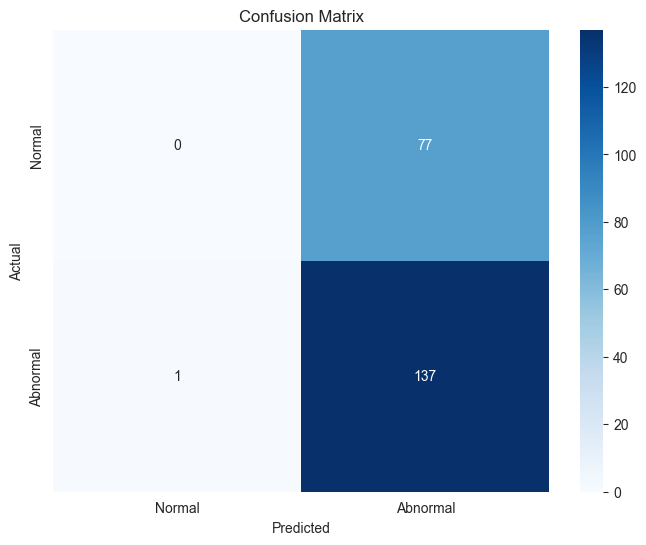

Optimal Threshold: 4794.2408
Accuracy: 0.7953
Precision: 0.8615
Recall: 0.8116
F1 Score: 0.8358


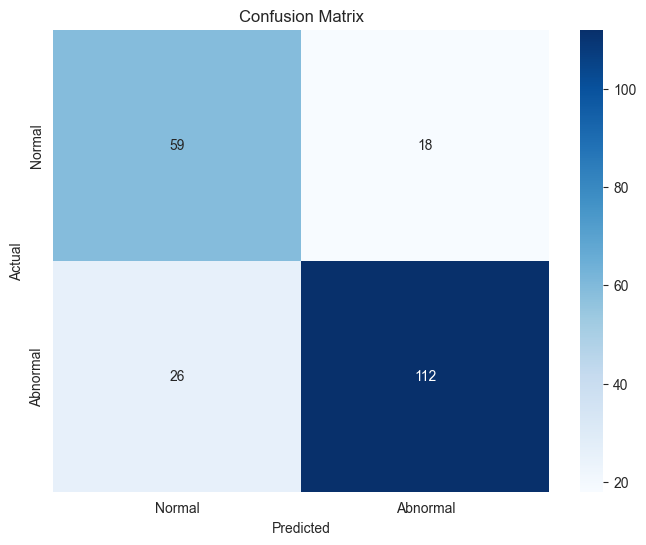

In [56]:
evaluate_tflite_model(interpreter=tflite_models["large_model_18in"], X_test=X_combined_test, Y_test=Y_combined_test)
evaluate_tflite_model(interpreter=tflite_models["large_model_5in"], X_test=X_combined_test_subset, Y_test=Y_combined_test_subset)

## Checking with Fp16, to see if the architecture is

using mixed precision to check this

In [57]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Dictionary: key = model name, value = file path
keras_models = {
    "model1_full_features_fp16": "autoencoder_model1.keras",
    "model2_topN_features_fp16": "autoencoder_model2(optimised).keras",
    "small_autoencoder_model_fp16": "small_autoencoder_model1.keras",
    "small_autoencoder_model_optimised_fp16": "small_autoencoder_model2(optimised).keras",
}

# Load FP16 (mixed precision) models

mixed_precision.set_global_policy("mixed_float16")

models_fp16 = {}
for name, path in keras_models.items():
    models_fp16[name] = tf.keras.models.load_model(path)

print("FP16 models loaded.")





# Latency Benchmark


def benchmark_latency(model, X, n_runs=20, warmup=3):

    def run():
        _ = unified_predict(model, X)

    # Warmup
    for _ in range(warmup):
        run()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        run()
        times.append(time.perf_counter() - t0)

    times = np.array(times)
    total_samples = X.shape[0]

    return {
        "latency_ms_per_batch_mean": float(times.mean() * 1000),
        "latency_ms_per_batch_p95": float(np.percentile(times, 95) * 1000),
        "ms_per_sample_mean": float(times.mean() * 1000 / total_samples),
        "samples_per_sec_mean": float(total_samples / times.mean()),
    }



# Load Models


model_configs = [
    {
        "name": "model1_full_features_fp16",
        "path": "autoencoder_model1.keras",
        "X": X_combined_test,
        "y": Y_combined_test,
        "type": "keras"
    },
    {
        "name": "model2_topN_features_fp16",
        "path": "autoencoder_model2(optimised).keras",
        "X": X_combined_test_subset,
        "y": Y_combined_test_subset,
        "type": "keras"
    },
    {
        "name": "small_autoencoder_model_fp16",
        "path": "small_autoencoder_model1.keras",
        "X": X_combined_test,
        "y": Y_combined_test,
        "type": "keras"
    },
    {
        "name": "small_autoencoder_model_optimised_fp16",
        "path": "small_autoencoder_model2(optimised).keras",
        "X": X_combined_test_subset,
        "y": Y_combined_test_subset,
        "type": "keras"
    }
]



# Benchmark Loop


rows = []

for config in model_configs:
    print(f"Benchmarking {config['name']}...")

    # Load model
    if config["type"] == "keras":
        model = models_fp16[config["name"]]
        params = int(model.count_params())
    else:
        model = tf.lite.Interpreter(model_path=config["path"])
        params = None  # TFLite does not expose param count

    # Metrics
    scores = anomaly_scores_mse(model, config["X"])
    auroc = roc_auc_score(config["y"], scores)
    auprc = average_precision_score(config["y"], scores)

    # Latency
    bench = benchmark_latency(model, config["X"])

    rows.append({
        "model": config["name"],
        "input_dim": int(config["X"].shape[1]),
        "params": params,
        "file_size_mb": model_file_size_mb(config["path"]),
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
        **bench
    })



# Final Results Table


df = pd.DataFrame(rows).sort_values("AUROC", ascending=False)
df.reset_index(drop=True, inplace=True)

df

C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 54 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\Likesh\Desktop\ACES\0.Coding\Rough\PyCharm\autoencoder\.venv\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


FP16 models loaded.
Benchmarking model1_full_features_fp16...
Benchmarking model2_topN_features_fp16...
Benchmarking small_autoencoder_model_fp16...
Benchmarking small_autoencoder_model_optimised_fp16...


,model,input_dim,params,file_size_mb,AUROC,AUPRC,latency_ms_per_batch_mean,latency_ms_per_batch_p95,ms_per_sample_mean,samples_per_sec_mean
0,model1_full_features_fp16,18,28242,0.403777,0.991436,0.995213,104.429335,113.680740,0.485718,2058.808476
1,small_autoencoder_model_fp16,18,2186,0.110700,0.977696,0.988676,101.985725,108.256500,0.474352,2108.138173
2,model2_topN_features_fp16,5,24901,0.365577,0.911632,0.961054,102.052615,109.190345,0.474663,2106.756402
3,small_autoencoder_model_optimised_fp16,5,1341,0.101026,0.906644,0.958947,104.970715,121.280400,0.488236,2048.190297
